# Exploring gold prices and daily returns

Goal of this notebook: load the gold price data we downloaded, look at it, and turn it into **daily returns** - the percentage change from one day's closing price to the next. This is the number that actually feeds into the volatility models (GARCH, and later the transformer).

Run each cell below in order (Shift+Enter).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the data

The CSV has a couple of extra header rows left over from how yfinance saves multiple tickers (the `Ticker` and `Date` label rows) - we skip those and tell pandas that the first column is a date, to use as the index (row label) instead of a plain column.

In [2]:
gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
gold.index.name = "Date"
gold.head()

,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## Look at the raw closing price

Just to see what we're working with before transforming anything.

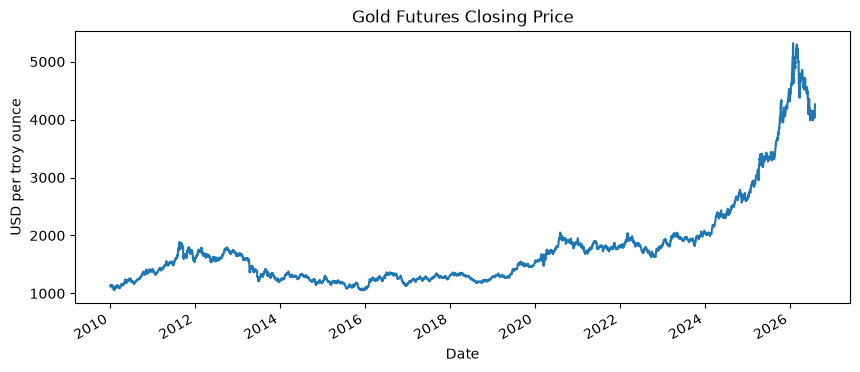

In [3]:
gold["Close"].plot(title="Gold Futures Closing Price", figsize=(10, 4))
plt.ylabel("USD per troy ounce")
plt.show()

## Compute daily returns

`pct_change()` computes, for each day, `(today's close - yesterday's close) / yesterday's close` - the percentage change from the previous day. The very first row has no "yesterday" to compare to, so it comes out as a missing value (`NaN`), which is expected.

In [4]:
gold["Return"] = gold["Close"].pct_change()
gold[["Close", "Return"]].head()

,Close,Return
Date,,
2010-01-04,1117.699951,NaN
2010-01-05,1118.099976,0.000358
2010-01-06,1135.900024,0.015920
2010-01-07,1133.099976,-0.002465
2010-01-08,1138.199951,0.004501


## Plot the returns

This is the chart that actually shows volatility: notice how the swings cluster together in calm stretches and stormy stretches, rather than being evenly sized throughout. That clustering pattern - calm periods and turbulent periods - is exactly what GARCH is designed to capture.

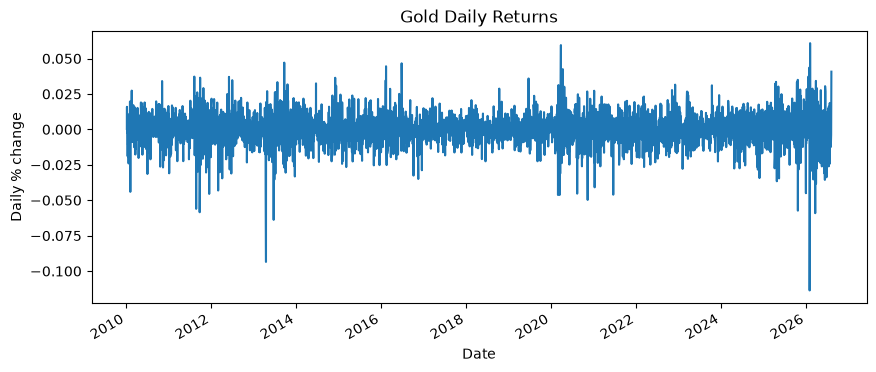

In [5]:
gold["Return"].plot(title="Gold Daily Returns", figsize=(10, 4))
plt.ylabel("Daily % change")
plt.show()